# Neighbour cluster

This notebook tests the neighbor cluster algorithm with different parameters. The goal is to find the best parameters to identify clusters of events in the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import os
from scipy.integrate import trapz

import matplotlib as mpl
# Set default figuresize and font size and labelsize for plots
plt.rcParams['figure.figsize'] = (14, 11)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

## Extract data

In [2]:
mockCR_n_CR = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/mockCR_dataset/n_CR_RUNs.npy",
                    allow_pickle=True
                    ).item()
mockCR_phi = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/mockCR_dataset/phi_RUNs.npy",
                    allow_pickle=True
                    ).item()
mockCR_theta = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/mockCR_dataset/theta_RUNs.npy",
                    allow_pickle=True
                    ).item()
mockCR_time = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/mockCR_dataset/time_RUNs.npy",
                    allow_pickle=True
                    ).item()

RUNs = np.array(list(mockCR_n_CR.keys()))
RUN_valid = RUNs[np.array([len(mockCR_time[run]) > 0 for run in RUNs])]

# Load extracted data
parasite_time_s = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/time_parasites.npy", 
                 allow_pickle=True
                 ).item()
parasite_theta = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/theta_parasites.npy", 
                     allow_pickle=True
                     ).item()
parasite_phi = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/phi_parasites.npy", 
                    allow_pickle=True
                    ).item()

obs_time_RUNs = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/observation_times.npy", 
                    allow_pickle=True).item()


# # Results of cluster algorithm

# mockCR_cluster = np.load(f"/sps/grand/jlavoisier/output/data_treatment/pipeline_eff/cluster_param/cluster_RUNs_5s_5deg.npy", 
#                  allow_pickle=True
#                  ).item()

# parasite_cluster = np.load(f"/sps/grand/jlavoisier/output/data_treatment/pipeline_eff/cluster_param/cluster_data_5s_5deg.npy", 
#                  allow_pickle=True
#                  ).item()

print(np.sum([mockCR_n_CR[run] for run in RUN_valid]))

487


In [3]:
print(RUNs)

['RUN10122' 'RUN10123' 'RUN10124' 'RUN10127' 'RUN10128' 'RUN10129'
 'RUN10130' 'RUN10132' 'RUN10143' 'RUN10141' 'RUN10136' 'RUN10131'
 'RUN10135' 'RUN10133' 'RUN10137' 'RUN10146' 'RUN10145' 'RUN10179'
 'RUN10176' 'RUN10177' 'RUN10180' 'RUN10178']


In [4]:
# print(len(list(parasite_time_s.values())))
print([len(parasite_time_s[run]) for run in RUN_valid])

[1242113, 281515, 108528, 34169, 1814122, 1078594, 308537, 33455, 14784, 210683, 317483, 244, 0, 0]


In [5]:
file_in_store = True

## Loop over multiple parameters

In [6]:

# loop_time_window = np.linspace(2, 30, 30)
loop_time_window = np.logspace(np.log10(.1), np.log10(1e5), 45)
loop_angle_window = np.arange(2, 47, 2)*np.pi/180

index_first_5s = np.where(loop_time_window >= 5)[0][0]
index_first_10deg = np.where(loop_angle_window >= 10*np.pi/180)[0][0]

cut_efficiency_grid_or = np.zeros((len(loop_time_window), len(loop_angle_window)))
loss_CR_grid_or = np.zeros((len(loop_time_window), len(loop_angle_window)))

In [7]:
print(np.floor(np.array(mockCR_time[RUN_valid[0]])))
print(np.array(parasite_time_s[RUN_valid[0]]) - np.min(parasite_time_s[RUN_valid[0]]))

[114711. 123908.  79572.  29527.  58675. 219643. 204988. 248657. 173269.
  78256. 193086. 167859.  62993. 121299. 140479. 141052.  36158. 275985.
  17362. 277651. 125039. 226228. 183786. 175728. 308779. 184245. 280950.
 292910.  88578. 234042. 231749. 296436. 204526. 210097.  81282. 173195.
    428.   1693. 302908.  53097. 208082. 117971. 186710. 241198.  63458.
 214818.  27032.  18232.  24296. 112213.  94108.]
[0.00000e+00 3.50000e+01 4.20000e+01 ... 3.15765e+05 3.15765e+05
 3.15765e+05]


In [8]:
if not file_in_store:
    cut_by_zenith = 0 # contains the number of events excluded by zenith cut

    cluster_pass = {}

    consecutive_events_cluster_or = np.array([])

    total_events= 0
    total_CR = 0
    indicator_full = np.array([])


    count_parasites_or = np.zeros((len(loop_time_window), len(loop_angle_window)))

    count_CR_or = np.zeros((len(loop_time_window), len(loop_angle_window)))




    for run in RUN_valid:
        if len(parasite_time_s[run]) == 0:
            continue
        time_event = np.array(parasite_time_s[run]) - np.min(parasite_time_s[run])
        theta_event = np.array(parasite_theta[run])
        phi_event = np.array(parasite_phi[run])
        # print(time_event)
        # print(theta_event)

        indicator = np.zeros(len(time_event))

        time_event = np.append(time_event, np.floor(np.array(mockCR_time[run])))
        theta_event = np.append(theta_event, np.array(mockCR_theta[run]*np.pi/180))
        phi_event = np.append(phi_event, np.array(mockCR_phi[run]*np.pi/180))

        # print(np.floor(np.array(mockCR_time[run])))
        # print(np.array(mockCR_theta[run]*np.pi/180))
        

        indicator = np.append(indicator, np.ones(len(mockCR_time[run])))

        sort = np.argsort(time_event)
        time_event = time_event[sort]
        theta_event = theta_event[sort]
        phi_event = phi_event[sort]

        indicator = indicator[sort]


        total_events += len(time_event)
        total_CR += len(mockCR_time[run])


        consecutive_mask = np.ones(len(time_event)-1, dtype=bool)

        time_between_consecutive = np.abs(time_event[1:]-time_event[:-1])
        theta_between_consecutive = np.abs(theta_event[1:]-theta_event[:-1])
        phi_between_consecutive = np.abs((phi_event[1:]-phi_event[:-1]+np.pi) % (2*np.pi) - np.pi)


        for i in range(len(loop_time_window)):
            for j in range(len(loop_angle_window)):
                consecutive_mask[np.all([time_between_consecutive < loop_time_window[i], 
                                         theta_between_consecutive < loop_angle_window[j], 
                                         phi_between_consecutive < loop_angle_window[j]], 
                                         axis=0)] = False

                test_cluster_neighbours_or = np.ones(len(time_event), dtype=bool) # False if both neighbour is in a cluster

                for k in range(len(time_event)):
                    if k == 0:
                        test_cluster_neighbours_or[k] = consecutive_mask[k]
                    elif k == len(time_event)-1:
                        test_cluster_neighbours_or[k] = consecutive_mask[k-1]
                    else:
                        test_cluster_neighbours_or[k] = consecutive_mask[k] or consecutive_mask[k-1] 

                count_parasites_or[i, j] += np.sum(test_cluster_neighbours_or[indicator==0])
                count_CR_or[i, j] += np.sum(test_cluster_neighbours_or[indicator==1])

                if i == index_first_5s and j == index_first_10deg:
                    cluster_pass[run] = test_cluster_neighbours_or[np.argsort(sort)]#[:len(parasite_time_s[run])] # sort back to original order

        
        # consecutive_events_cluster_and = np.append(consecutive_events_cluster_and, test_cluster_neighbours_and)
        # consecutive_events_cluster_or = np.append(consecutive_events_cluster_or, test_cluster_neighbours_or)
        # indicator_full = np.append(indicator_full, indicator)
        # break

    for i in range(len(loop_time_window)):
        for j in range(len(loop_angle_window)):
            cut_efficiency_grid_or[i, j] = 100 - count_parasites_or[i, j]/total_events*100
            loss_CR_grid_or[i, j] = 100 - count_CR_or[i, j]/total_CR*100


    np.save(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/cluster_results/cluster_cut_efficiency.npy", cut_efficiency_grid_or)
    np.save(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/cluster_results/cluster_loss.npy", loss_CR_grid_or)
    np.save(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/cluster_results/cluster_pass_5s_10deg.npy", cluster_pass)

In [9]:
if file_in_store:
    cut_efficiency_grid_or = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/cluster_results/cluster_cut_efficiency.npy")
    loss_CR_grid_or = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/cluster_results/cluster_loss.npy")
    cluster_pass = np.load(f"/sps/grand/jlavoisier/code/quantification/cluster_neighbour_quant/cluster_results/cluster_pass_5s_10deg.npy",
                           allow_pickle=True
                        ).item()

## Plots and tables

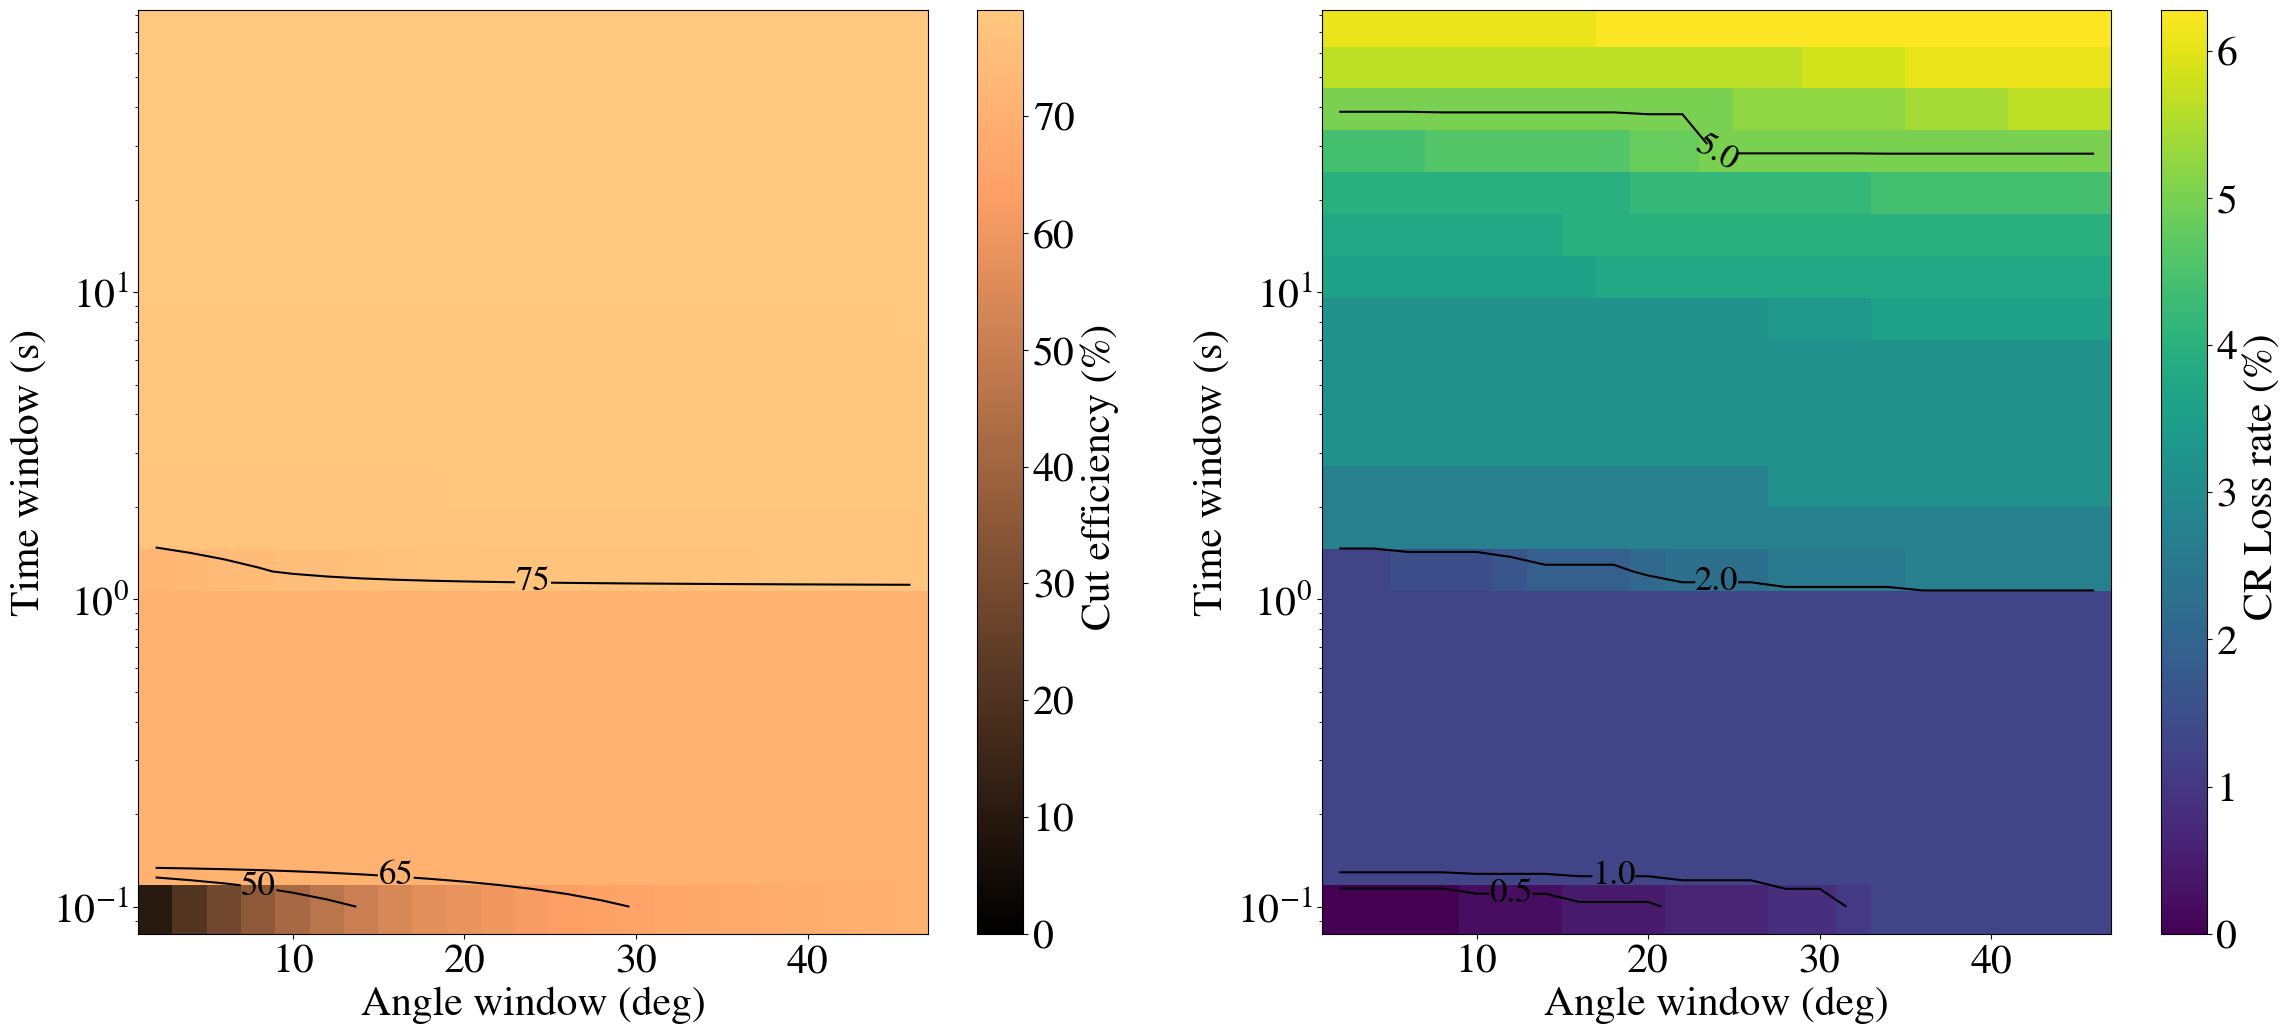

In [10]:

Xmin = 0.1
index_plot_min = np.argmin(np.abs(loop_angle_window*180/np.pi - Xmin))
Xmax = 100
index_plot_max = np.argmin(np.abs(loop_angle_window*180/np.pi - Xmax))



fig, ax = plt.subplots(1, 2, figsize=(28, 12))
# Plot using pcolor

X0, Y0 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

im0 = ax[0].pcolor(X0,
                   Y0,
                   cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
                   cmap='copper', 
                #    aspect='auto',
                   # origin='lower',
                   norm=mpl.colors.Normalize(
                                    #  vmin=cut_efficiency_grid_or[index_plot_min:index_plot_max, :].min(), 
                                     vmin=0,
                                    #  vmax=100,
                                     vmax= cut_efficiency_grid_or[index_plot_min:index_plot_max, :].max(),
                                     ),
           )

CS = ax[0].contour(X0,
                   Y0,
                   cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
              np.array([50, 65, 75, 95]), 
              colors='k', 
              origin='lower', 
            #   extent=extent
              )
ax[0].clabel(CS, fontsize=25)

        
fig.colorbar(im0, ax=ax[0], label='Cut efficiency (%) ')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'Angle window (deg)',
           fontsize=30
           )
ax[0].set_ylabel('Time window (s)', 
           fontsize=30
           )
# ax[0].set_ylim(
#             #    ymin=1, 
#                ymax=100
#                )
# ax[0].set_title(
#     'Cut efficiency Heatmap', 
#                 fontsize=35
#                 )


X1, Y1 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

im1 = ax[1].pcolor(X1,
                   Y1,
                   loss_CR_grid_or[index_plot_min:index_plot_max, :], 
                    cmap='viridis', 
                    # aspect='auto',
                    # origin='lower',
                    norm=mpl.colors.Normalize(
                                                vmin=0,
                                                #  vmax=100,
                                                vmax=loss_CR_grid_or[index_plot_min:index_plot_max, :].max()
                                                ),
                    )

CS = ax[1].contour(X1,
                   Y1,
                   loss_CR_grid_or[index_plot_min:index_plot_max, :], 
              np.array([0.5, 1, 2, 5, 10]), 
              colors='k', 
            #   origin='lower', 
            #   extent=extent
              )
ax[1].clabel(CS, fontsize=25)

# # Loop over data dimensions and create text annotations.
# for i in range(1, len(loop_time_window), 3):
#     for j in range(1, len(loop_angle_window), 3):
#         text = ax[1].text(j, i, 
#                         f"{loss_CR_grid_or[i, j]:.0f}",
#                        ha="center", 
#                        va="center", 
#                        color="black")
        
fig.colorbar(im1, ax=ax[1], label='CR Loss rate (%) ')

ax[1].set_yscale('log')
ax[1].set_xlabel(r'Angle window (deg)',
           fontsize=30
           )
ax[1].set_ylabel('Time window (s)', 
           fontsize=30
           )

# ax[1].set_ylim(
#             #    ymin=1, 
#                ymax=100
#                )
# ax[1].set_title('Loss rate Heatmap', 
#                 fontsize=35
#                 )

# fig.suptitle('Neighbour cluster (restrictive case)')
plt.show()


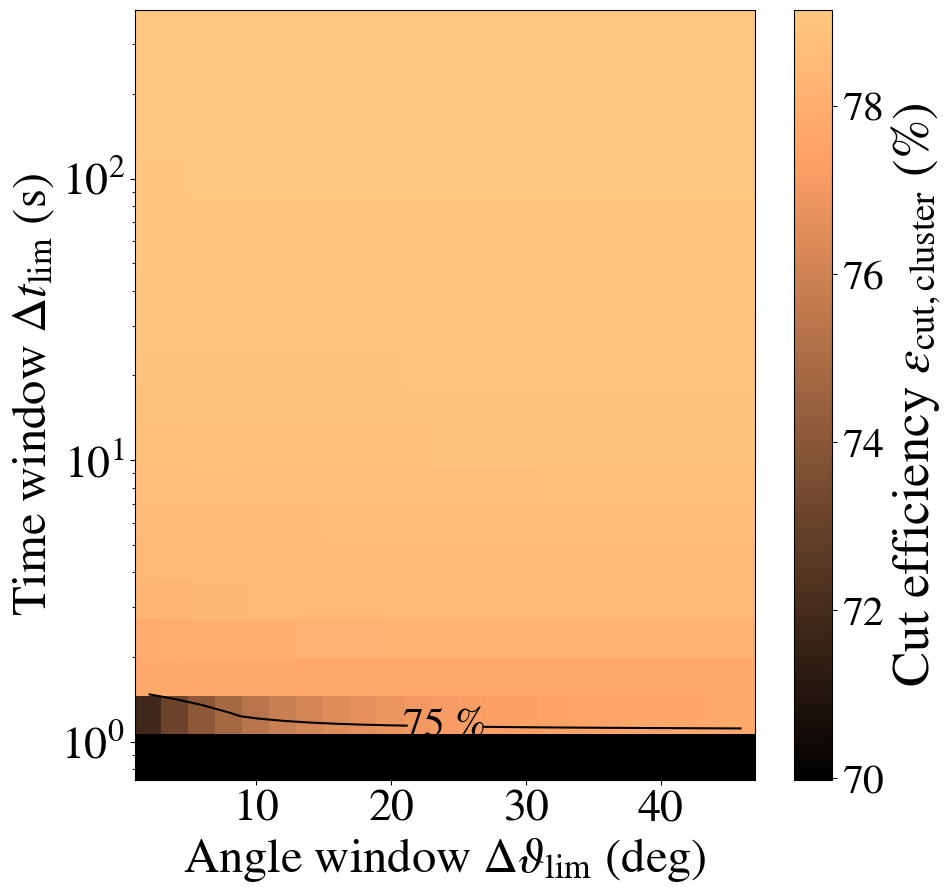

In [53]:
Xmin = 1
index_plot_min = np.argmin(np.abs(loop_time_window - Xmin))
Xmax = 500
index_plot_max = np.argmin(np.abs(loop_time_window - Xmax))


def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"

plt.figure(figsize=(10, 10))
# Plot using pcolor

X0, Y0 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

im0 = plt.pcolor(X0,
                   Y0,
                   cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
                   cmap='copper', 
                #    aspect='auto',
                   # origin='lower',
                    rasterized=True,
                   norm=mpl.colors.Normalize(
                                     vmin=cut_efficiency_grid_or[index_plot_min:index_plot_max, :].min(), 
                                    #  vmin=0,
                                    #  vmax=100,
                                     vmax= cut_efficiency_grid_or[index_plot_min:index_plot_max, :].max(),
                                     ),
           )

CS = plt.contour(X0,
                   Y0,
                   cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
              np.array([50, 65, 75, 95]), 
              colors='k', 
              origin='lower', 
            #   extent=extent
              )
plt.clabel(CS, 
           fmt=fmt,
           fontsize=30
           )

        
cbar = plt.colorbar(im0, 
            #  ax=ax, 
            #  label='Cut efficiency (%) ',
            #  fontsize=35
             )
cbar.ax.tick_params(labelsize=30
                    )
cbar.set_label(r'Cut efficiency $\varepsilon_{\rm cut, cluster}$ (%)', 
               fontsize=38
               )

plt.yscale('log')
plt.xlabel(r'Angle window $\Delta \vartheta_{\rm lim}$ (deg)',
           fontsize=35
           )
plt.xticks([10, 20, 30, 40],)
plt.ylabel(r'Time window $\Delta t_{\rm lim}$ (s)', 
           fontsize=35
           )
plt.tick_params(axis='both', 
                which='major', 
                labelsize=33
                )
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_cut_efficiency.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()


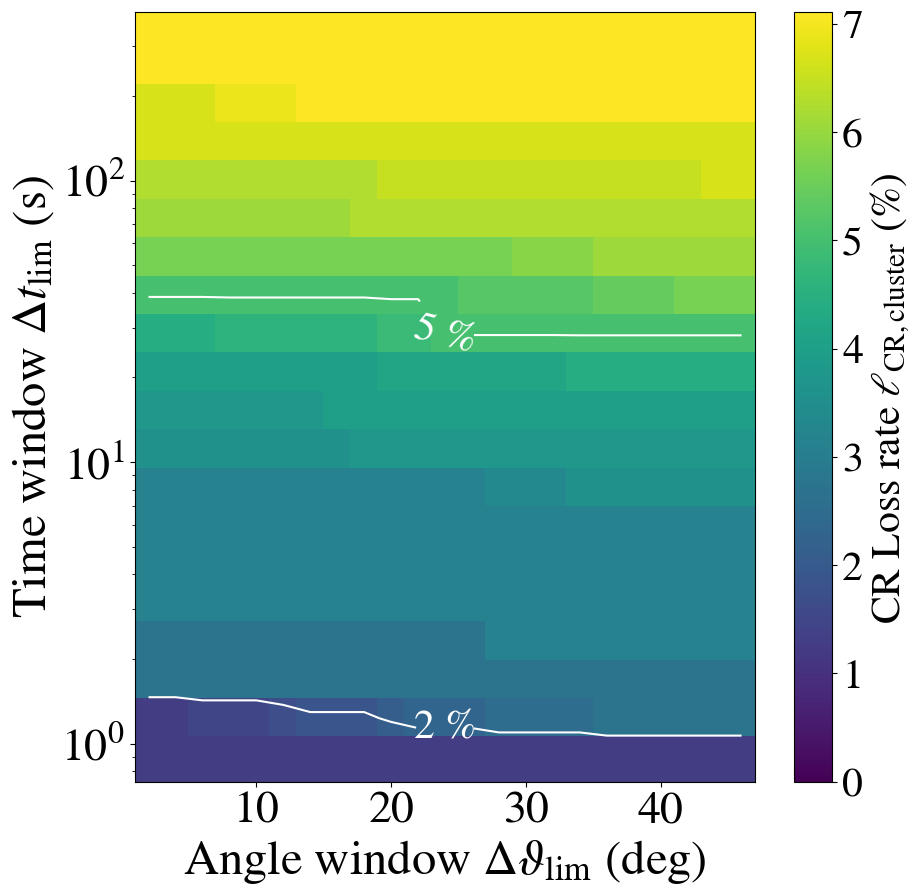

In [54]:

plt.figure(figsize=(10, 10))

X1, Y1 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

im1 = plt.pcolor(X1,
                   Y1,
                   loss_CR_grid_or[index_plot_min:index_plot_max, :], 
                    cmap='viridis', 
                    # aspect='auto',
                    # origin='lower',
                    rasterized=True,
                    norm=mpl.colors.Normalize(
                                                vmin=0,
                                                #  vmax=100,
                                                vmax=loss_CR_grid_or[index_plot_min:index_plot_max, :].max()
                                                ),
                    )

CS = plt.contour(X1,
                   Y1,
                   loss_CR_grid_or[index_plot_min:index_plot_max, :], 
              np.array([0.5, 1, 2, 5, 10]), 
              colors='white', 
            #   origin='lower', 
            #   extent=extent
              )
plt.clabel(CS, 
           fontsize=30,
           fmt=fmt
           )

# # Loop over data dimensions and create text annotations.
# for i in range(1, len(loop_time_window), 3):
#     for j in range(1, len(loop_angle_window), 3):
#         text = ax[1].text(j, i, 
#                         f"{loss_CR_grid_or[i, j]:.0f}",
#                        ha="center", 
#                        va="center", 
#                        color="black")
        
plt.colorbar(im1, 
            #  ax=ax, 
             label=r'CR Loss rate $\ell_{\rm CR, cluster}$ (%) '
             )

cbar.ax.tick_params(labelsize=30
                    )
cbar.set_label('Cut efficiency (%)', 
               fontsize=38
               )

plt.yscale('log')
plt.xlabel(r'Angle window $\Delta \vartheta_{\rm lim}$ (deg)',
           fontsize=35
           )
plt.xticks([10, 20, 30, 40],)
plt.ylabel(r'Time window $\Delta t_{\rm lim}$ (s)', 
           fontsize=35
           )
plt.tick_params(axis='both', 
                which='major', 
                labelsize=33
                )
plt.grid(False)
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_loss.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()


In [13]:
print(cut_efficiency_grid_or.min())

10.438398407259896


## Fix an angle and look at cut eff vs loss rate for time window

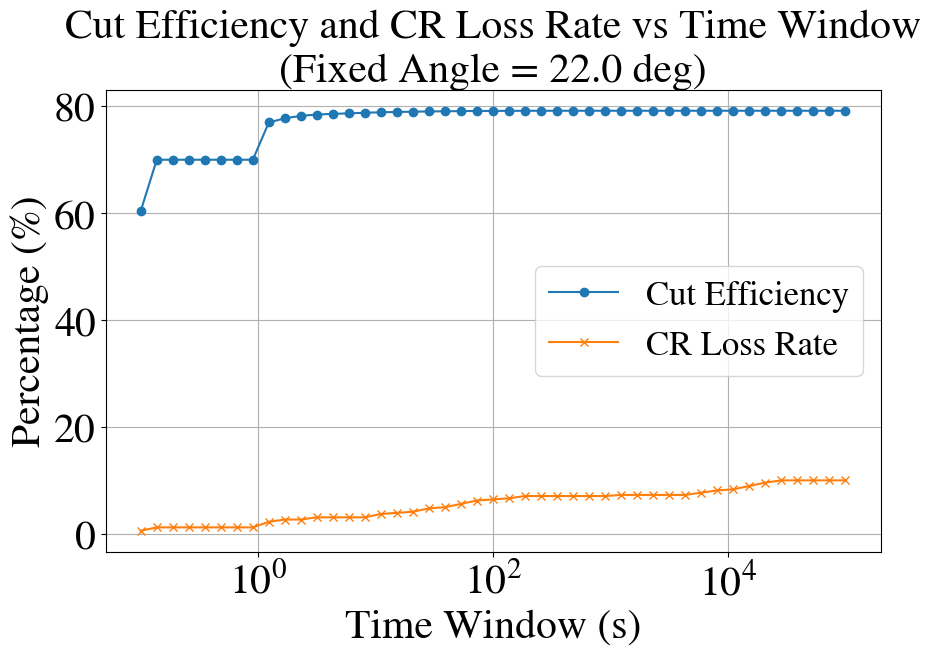

In [14]:
index_fixed_angle = 10

fixed_angle = loop_angle_window[index_fixed_angle]  # Example: fix the angle at the 10th index of loop_angle_window


table_cut_efficiency = cut_efficiency_grid_or[:, index_fixed_angle]
table_loss_CR = loss_CR_grid_or[:, index_fixed_angle]


plt.figure(figsize=(10, 6))
plt.plot(loop_time_window, 
            table_cut_efficiency, 
            marker='o', 
            label='Cut Efficiency'
            )
plt.plot(loop_time_window, 
            table_loss_CR, 
            marker='x', 
            label='CR Loss Rate'
            )
plt.xscale('log')
plt.xlabel('Time Window (s)')
plt.ylabel('Percentage (%)')
plt.title(f'Cut Efficiency and CR Loss Rate vs Time Window\n(Fixed Angle = {fixed_angle*180/np.pi:.1f} deg)')
# plt.title(f'Cut Efficiency and CR Loss Rate vs Time Window at fixed angle')
plt.legend()
plt.grid(True)
plt.show()

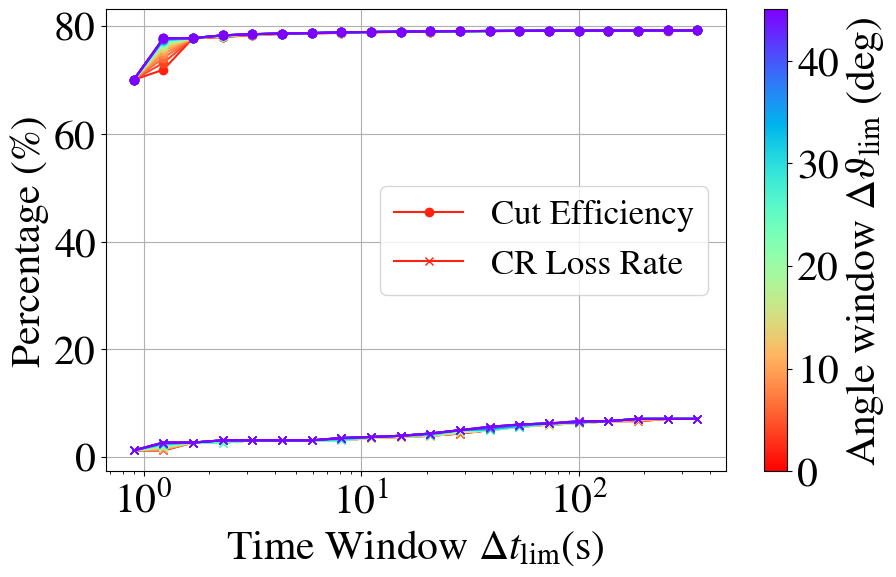

In [ ]:

index_fixed_angle = 10
fixed_angle = loop_angle_window[index_fixed_angle]  # Example: fix the angle at the 10th index of loop_angle_window


cmap_angle = plt.colormaps['rainbow_r']
norm = mpl.colors.Normalize(vmin=0, vmax=45)

plt.figure(figsize=(10, 6))
ax = plt.gca()

for i in range(len(loop_angle_window)):
    color = cmap_angle(norm(loop_angle_window[i] * 180 / np.pi))
    plt.plot(loop_time_window[index_plot_min:index_plot_max],
             cut_efficiency_grid_or[index_plot_min:index_plot_max, i],
             color=color,
             marker='o',
             label=f'Cut Efficiency' if i == 0 else ""
             )
    
    plt.plot(loop_time_window[index_plot_min:index_plot_max],
             loss_CR_grid_or[index_plot_min:index_plot_max, i],
             color=color,
             marker='x',
             label=f'CR Loss Rate' if i == 0 else ""
             )

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_angle, norm=norm)
sm.set_array([])  # This is required for the colorbar to work

fig = plt.gcf()
fig.colorbar(sm, ax=ax, label=r"Angle window $\Delta \vartheta_{\rm lim}$ (deg)")

plt.xscale('log')
plt.xlabel(r'Time Window $\Delta t_{\rm lim}$(s)')
plt.ylabel('Percentage (%)')
# plt.title(f'Cut Efficiency and CR Loss Rate vs Time Window at fixed angle')
plt.legend()
plt.grid(True)
# plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_loss_cuteff.pdf",
#             format='pdf', 
#             dpi=300, 
#             bbox_inches = "tight"
#             )
plt.show()

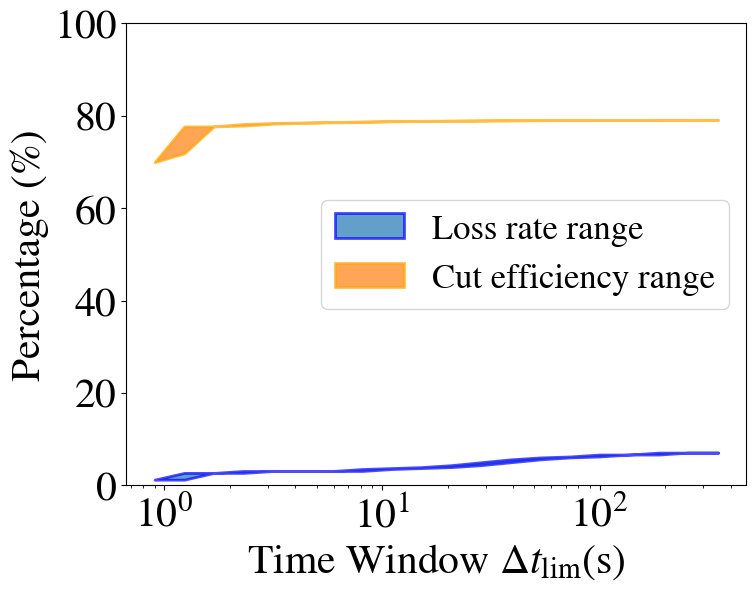

In [60]:
plt.figure(figsize=(8, 6))

plt.fill_between(loop_time_window[index_plot_min:index_plot_max],
                 loss_CR_grid_or[index_plot_min:index_plot_max, 0],
                 loss_CR_grid_or[index_plot_min:index_plot_max, -1],
                 color='tab:blue',
                 alpha=0.7,
                 label='Loss rate range',
                 edgecolor='blue',
                 linewidth=2
                 )

plt.fill_between(loop_time_window[index_plot_min:index_plot_max],
                 cut_efficiency_grid_or[index_plot_min:index_plot_max, 0],
                 cut_efficiency_grid_or[index_plot_min:index_plot_max, -1],
                 color='tab:orange',
                 alpha=0.7,
                 label='Cut efficiency range',
                 edgecolor='orange',
                 linewidth=2
                 )

plt.xscale('log')
plt.xlabel(r'Time Window $\Delta t_{\rm lim}$(s)')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
# plt.title(f'Cut Efficiency and CR Loss Rate vs Time Window at fixed angle')
plt.legend()

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_loss_cuteff.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )




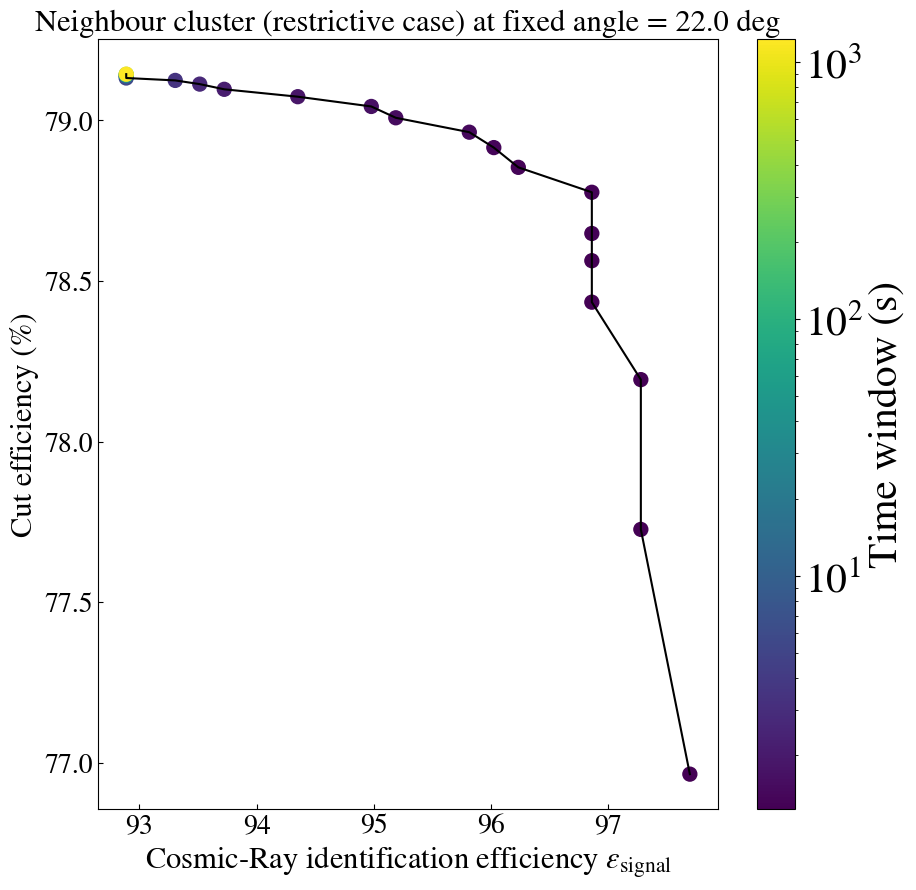

In [16]:
cmap_angle = plt.colormaps['winter']
norm = mpl.colors.Normalize(vmin=0, vmax=45)

index_min_time = np.where(loop_time_window >= 1)[0][0]
index_max_time = np.where(loop_time_window >= 1e3)[0][0]

fig = plt.figure(figsize=(10, 10))
# plt.subplots(dpi=200)



plt.plot(100 - loss_CR_grid_or[index_min_time:index_max_time, index_fixed_angle],
        cut_efficiency_grid_or[index_min_time:index_max_time, index_fixed_angle],
        color="k"
        )
plt.scatter(100 - loss_CR_grid_or[index_min_time:index_max_time, index_fixed_angle],
            cut_efficiency_grid_or[index_min_time:index_max_time, index_fixed_angle],
            c=loop_time_window[index_min_time:index_max_time],
            s=100
            )

plt.xlabel("Cosmic-Ray identification efficiency " + r"$\varepsilon_{\text{signal}}$",
            # r"$\varepsilon_{\text{signal}}$",
                    fontsize=22)

plt.ylabel("Cut efficiency (%)",
            # r"$1 - \varepsilon_{\text{background}}$",
                    fontsize=22)
plt.tick_params(axis='x', 
                    labelsize=20,
                    direction="in"
                    )
plt.tick_params(axis='y', 
                    labelsize=20,
                    direction="in"
                    )
# plt.ylim(0, 100)
# plt.xlim(0, 100)
# plt.xticks(np.array([0, 0.2, 0.4, 0.6, 0.8, 1])*100,)


# Create a ScalarMappable for the colorbar
norm = mpl.colors.LogNorm(
                            # vmin=loop_time_window.min(), 
                            vmin=loop_time_window[index_min_time],
                            # vmax=loop_time_window.max(),
                            vmax=loop_time_window[index_max_time]
                            )
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # This is required for the colorbar to work

ax = plt.gca()
cbar = plt.gcf()
cbar.colorbar(sm, ax=ax, label=r"Time window (s)")
# cbar.ax.tick_params(labelsize=20)

plt.title(f"Neighbour cluster (restrictive case) at fixed angle = {fixed_angle*180/np.pi:.1f} deg",
            fontsize=22
            )

# fig.tight_layout()
plt.show()

## Histograms of time of trigger for a few runs

In [17]:
max = 0
RUN_max = ""
for i in RUN_valid:
    if len(parasite_time_s[i]) == 0:
        continue
    print(f"RUN {i}: {len(parasite_time_s[i])} parasites, {len(mockCR_time[i])} CRs")
    print(f"{i} clsuter pass: {np.sum(cluster_pass[i])} events")
    # print(f"{i} observation time: {obs_time_RUNs[i]/3600:.2f} h")
    if len(parasite_time_s[i]) > max:
        max = len(parasite_time_s[i])
        RUN_max = i
print(f"RUN with max parasites: {RUN_max} with {max} parasites")


RUN RUN10127: 1242113 parasites, 51 CRs
RUN10127 clsuter pass: 183257 events
RUN RUN10128: 281515 parasites, 18 CRs
RUN10128 clsuter pass: 23036 events
RUN RUN10129: 108528 parasites, 107 CRs
RUN10129 clsuter pass: 26875 events
RUN RUN10130: 34169 parasites, 111 CRs
RUN10130 clsuter pass: 12217 events
RUN RUN10132: 1814122 parasites, 64 CRs
RUN10132 clsuter pass: 589017 events
RUN RUN10143: 1078594 parasites, 1 CRs
RUN10143 clsuter pass: 185762 events
RUN RUN10141: 308537 parasites, 13 CRs
RUN10141 clsuter pass: 85687 events
RUN RUN10131: 33455 parasites, 63 CRs
RUN10131 clsuter pass: 10163 events
RUN RUN10133: 14784 parasites, 11 CRs
RUN10133 clsuter pass: 7870 events
RUN RUN10146: 210683 parasites, 9 CRs
RUN10146 clsuter pass: 16676 events
RUN RUN10145: 317483 parasites, 2 CRs
RUN10145 clsuter pass: 23190 events
RUN RUN10179: 244 parasites, 28 CRs
RUN10179 clsuter pass: 82 events
RUN with max parasites: RUN10132 with 1814122 parasites


RUN RUN10132: 1814122 parasites, 1225162 cut by cluster, 588960 passed by cluster
Fraction cut: 67.53%


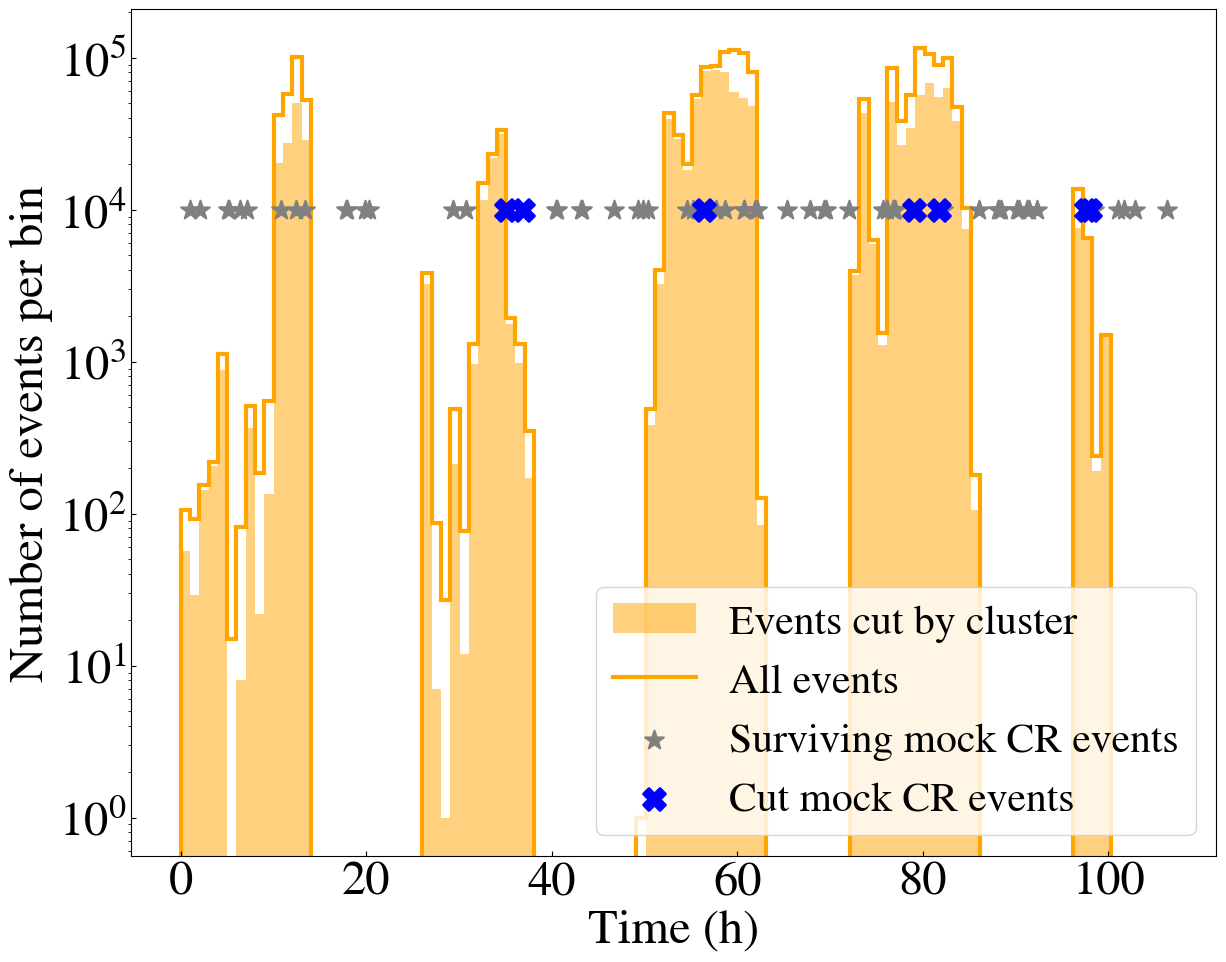

Size of bins: 60.13 min


In [18]:
parasite_max = (np.array(parasite_time_s[RUN_max]) - np.min(parasite_time_s[RUN_max]))/3600
cluster_pass_parasite_max = cluster_pass[RUN_max][:len(parasite_max)]
cluster_pass_CR_max = cluster_pass[RUN_max][len(parasite_max):]
cut_parasite_max = parasite_max[~cluster_pass_parasite_max]
surv_CR_max = mockCR_time[RUN_max][cluster_pass_CR_max]
cut_CR_max = mockCR_time[RUN_max][~cluster_pass_CR_max]

print(f"RUN {RUN_max}: {len(parasite_max)} parasites, {len(cut_parasite_max)} cut by cluster, {len(parasite_max)-len(cut_parasite_max)} passed by cluster")
print(f"Fraction cut: {len(cut_parasite_max)/len(parasite_max)*100:.2f}%")

hist_par_max, bin_edges = np.histogram(parasite_max, bins=100)
hist_pass_max, bin_edges = np.histogram(cut_parasite_max, bins=bin_edges)

# plt.hist(parasite_max, 
#          bins=bin_edges, 
#          color='blue', 
#          alpha=0.7,
#          rasterized=True,
#          label='All events'
#          )

# plt.rcParams['hatch.linewidth'] = 1.5

# plt.stairs(hist_pass_max, 
#          edges=bin_edges, 
#          color="#f18f01", 
#         #  fill=True,
#          hatch='//',
#         #  alpha=0.7,
#          linewidth=3,
#          label='Events cut by cluster'
#          )


plt.hist(cut_parasite_max, 
         bins=bin_edges, 
         color='orange', 
         alpha=0.5,
         rasterized=True,
         label='Events cut by cluster'
         )

plt.stairs(hist_par_max, 
         edges=bin_edges, 
         color='orange', 
        #  hatch='//',
        #  alpha=0.7,
         linewidth=3,
         label='All events'
         )


plt.scatter(surv_CR_max/3600, 
            np.zeros(len(surv_CR_max))+1e4, 
            # color="#ffcf0f", 
            color="grey",
            marker='*', 
            linewidth=1.5,
            s=200, 
            label='Surviving mock CR events',
            # edgecolors='black'
            )

plt.scatter(cut_CR_max/3600, 
            np.zeros(len(cut_CR_max))+1e4, 
            # color="#3b48f6", 
            color="blue",
            marker='X', 
            linewidth=2,
            # edgecolors='black',
            s=250, 
            label='Cut mock CR events'
            )

plt.xlabel('Time (h)',
            fontsize=35
            )
plt.yscale('log')
plt.ylabel('Number of events per bin',
            fontsize=35
            )
plt.tick_params(axis='both', 
                labelsize=35,
                direction="in"
                )
plt.legend(loc="lower right",
    fontsize=30)
# plt.title(f'Histogram of parasite events for {RUN_max}')
# plt.grid()

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_time_distrib_{RUN_max}_{len(parasite_max)}-parasites.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )

plt.show()

print(f"Size of bins: {(bin_edges[1]-bin_edges[0])*60:.2f} min")

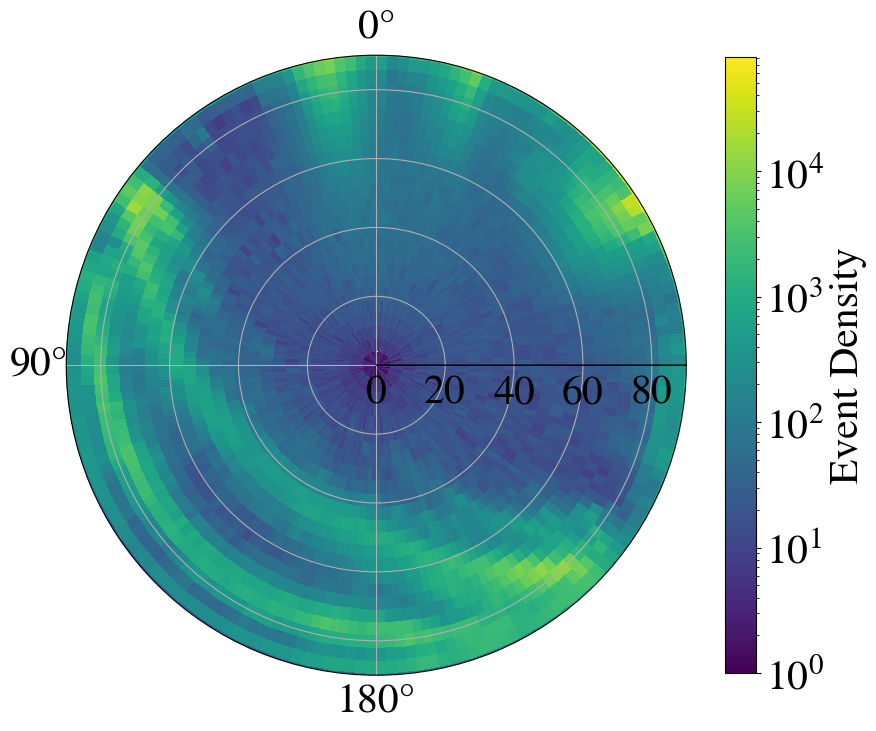

In [52]:
theta_max = np.array(parasite_theta[RUN_max])
phi_max = np.array(parasite_phi[RUN_max])

cut_theta_max = theta_max[~cluster_pass_parasite_max]
cut_phi_max = phi_max[~cluster_pass_parasite_max]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location("N")
# ax.set_theta_direction(-1)
# ax.scatter(phi_max,
#             theta_max*180/np.pi,
#             color='blue',
#             alpha=0.7,
#             label='All events'
#             )

hist = ax.hist2d(phi_max-np.pi/2,
                theta_max*180/np.pi,
                bins=[180, 45],
                cmap='viridis',
                # alpha=0.7,
                label='All events',
                norm=mpl.colors.LogNorm(),
                rasterized=True
                )

plt.colorbar(hist[3], 
             ax=ax, 
             label='Event Density',
            #  pad=0.08,
             shrink=0.8
             )
ax.set_ylim(0, 90)
ax.tick_params(axis="x",
               pad=9,
               )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_polar_distrib_{RUN_max}_{len(parasite_max)}-parasites.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )

plt.show()

/scratch/users/j/jlavoisier/ipykernel_216795/3879918565.py:62: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(fontsize=25,


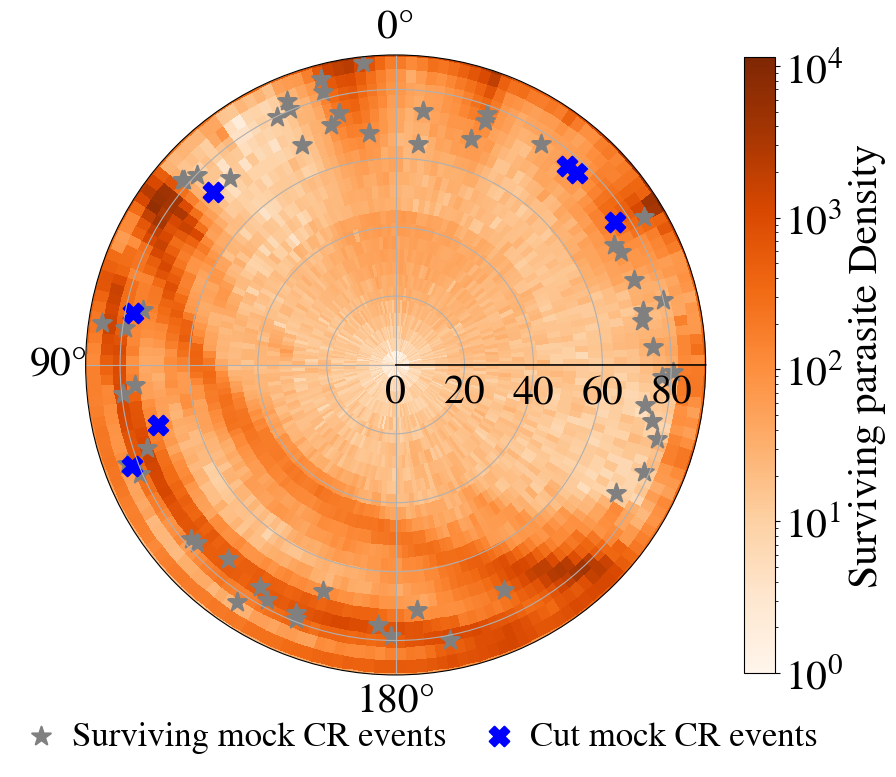

In [51]:
cut_theta_max = theta_max[cluster_pass_parasite_max]
cut_phi_max = phi_max[cluster_pass_parasite_max]

surv_CR_theta_max = np.array(mockCR_theta[RUN_max]*np.pi/180)[cluster_pass_CR_max]
surv_CR_phi_max = np.array(mockCR_phi[RUN_max]*np.pi/180)[cluster_pass_CR_max]
cut_CR_theta_max = np.array(mockCR_theta[RUN_max]*np.pi/180)[~cluster_pass_CR_max]
cut_CR_phi_max = np.array(mockCR_phi[RUN_max]*np.pi/180)[~cluster_pass_CR_max]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location("N")
# ax.scatter(phi_max,
#             theta_max*180/np.pi,
#             color='blue',
#             alpha=0.7,
#             label='All events'
#             )

hist = ax.hist2d(cut_phi_max-np.pi/2,
                cut_theta_max*180/np.pi,
                bins=[180, 45],
                cmap='Oranges',
                # alpha=0.7,
                label='All events',
                norm=mpl.colors.LogNorm(),
                rasterized=True
                )

plt.scatter(surv_CR_phi_max-np.pi/2, 
            surv_CR_theta_max*180/np.pi, 
            color="grey",
            marker='*', 
            linewidth=1.5,
            s=200, 
            label='Surviving mock CR events',
            # edgecolors='black'
            )

plt.scatter(cut_CR_phi_max-np.pi/2, 
            cut_CR_theta_max*180/np.pi, 
            color="blue",
            marker='X', 
            linewidth=1.5,
            s=200, 
            label='Cut mock CR events',
            # edgecolors='black'
            )


plt.colorbar(hist[3], 
             ax=ax, 
             label='Surviving parasite Density',
            #  pad=0.08,
             shrink=0.8
             )
ax.set_ylim(0, 90)

ax.tick_params(axis="x",
               pad=9,
               )

plt.legend(fontsize=25,
           loc='center left', 
           bbox_to_anchor=(-0.15, -0.15, 1, 0.1),
           ncol=2,
           columnspacing=1,
           handletextpad=0.4,
           handlelength=1,
           frameon=False
           )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_polar_distrib_{RUN_max}_{len(cut_theta_max)}-cutparasites.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )


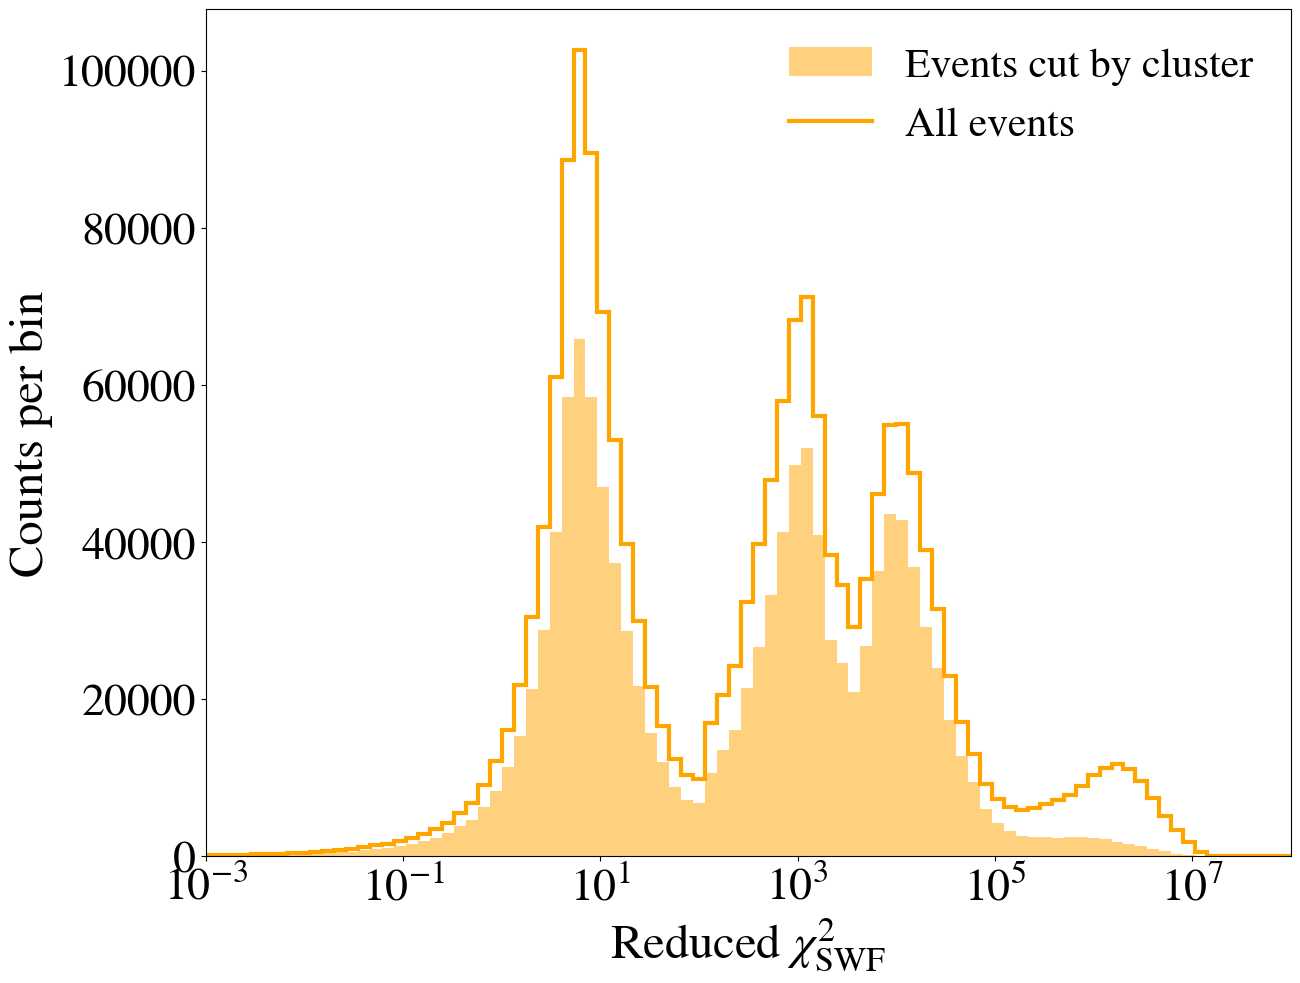

In [ ]:
parasites_chi2_SWF_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/chi2_SWF_parasites.npy",
                    allow_pickle=True
                    ).item()

parasite_chi2_max = np.array(parasites_chi2_SWF_RUN[RUN_max])

logbins = np.logspace(-4, 8, 100)

# plt.hist(parasite_chi2_max,
#          bins=logbins,
#          color='blue',
#          alpha=0.7,
#          rasterized=True,
#          label='All events'
#          )

# hist_chi2_cut_max, _ = np.histogram(parasite_chi2_max[~cluster_pass_parasite_max], bins=logbins)

# plt.stairs(hist_chi2_cut_max,
#          edges=logbins, 
#          color="#f18f01", 
#         #  fill=True,
#          hatch='//',
#         #  alpha=0.7,
#          linewidth=3,
#          label='Events cut by cluster'
#          )



plt.hist(parasite_chi2_max[~cluster_pass_parasite_max], 
         bins=logbins, 
         color='orange', 
         alpha=0.5,
         rasterized=True,
         label='Events cut by cluster'
         )

hist_par_max, logbins = np.histogram(parasite_chi2_max, bins=logbins)
plt.stairs(hist_par_max, 
         edges=logbins, 
         color='orange', 
        #  hatch='//',
        #  alpha=0.7,
         linewidth=3,
         label='All events'
         )

plt.xscale('log')
plt.xlim(1e-3, 1e8)
plt.legend()
plt.xlabel(r'Reduced $\chi^2_{\rm SWF}$',
           fontsize=35
           )
plt.ylabel('Counts per bin',
           fontsize=35
           )
plt.tick_params(axis='both',
                labelsize=33,
                # direction="in"
                )
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm PWF}$')
plt.legend(fontsize=30,
           frameon=False
           )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_chi2SWF_distrib_{RUN_max}_{len(cut_theta_max)}-cutparasites.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )

plt.show()

RUN10146


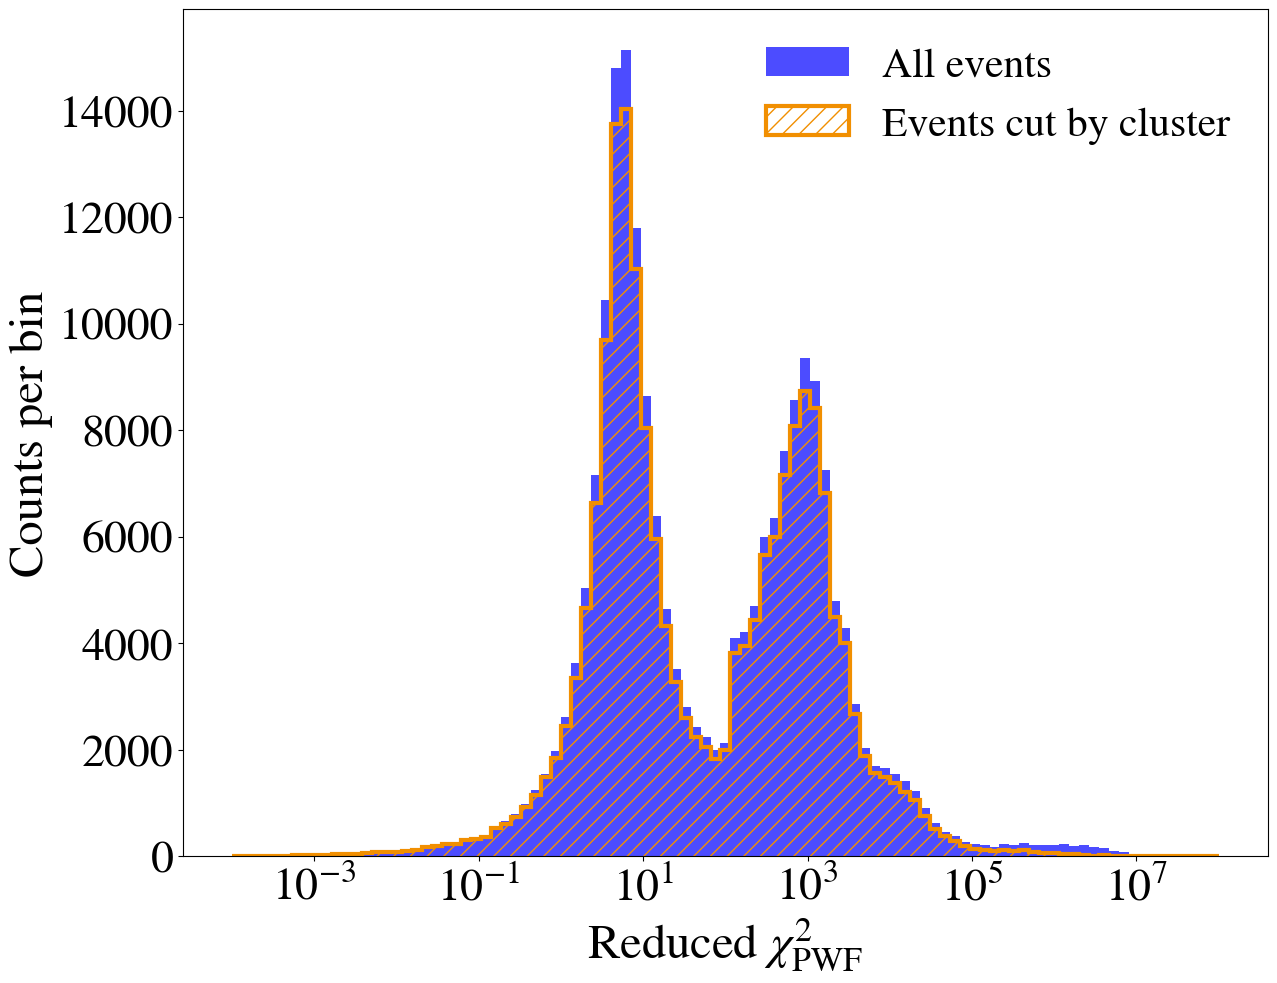

In [ ]:
run_coincidental_parasite = RUN_valid[9]
print(run_coincidental_parasite)

chi2_SWF_coincidental_parasite = np.array(parasites_chi2_SWF_RUN[run_coincidental_parasite])

cluster_pass_parasite_max = cluster_pass[run_coincidental_parasite][:len(chi2_SWF_coincidental_parasite)]
hist_chi2_cut_coincidental, _ = np.histogram(chi2_SWF_coincidental_parasite[~cluster_pass_parasite_max], 
                                             bins=logbins
                                             )

plt.hist(chi2_SWF_coincidental_parasite,
         bins=logbins,
         color='blue',
         alpha=0.7,
         rasterized=True,
         label='All events'
         )

plt.stairs(hist_chi2_cut_coincidental,
         edges=logbins, 
         color="#f18f01", 
        #  fill=True,
         hatch='//',
        #  alpha=0.7,
         linewidth=3,
         label='Events cut by cluster'
         )

plt.xscale('log')
# plt.xlim(1, 1e8)
plt.legend()
plt.xlabel(r'Reduced $\chi^2_{\rm PWF}$',
           fontsize=35
           )
plt.ylabel('Counts per bin',
           fontsize=35
           )
plt.tick_params(axis='both',
                labelsize=33,
                # direction="in"
                )
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm PWF}$')
plt.legend(fontsize=30,
           frameon=False
           )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/cluster_chi2PWF_distrib_{RUN_max}_{len(cut_theta_max)}-cutparasites.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )

plt.show()

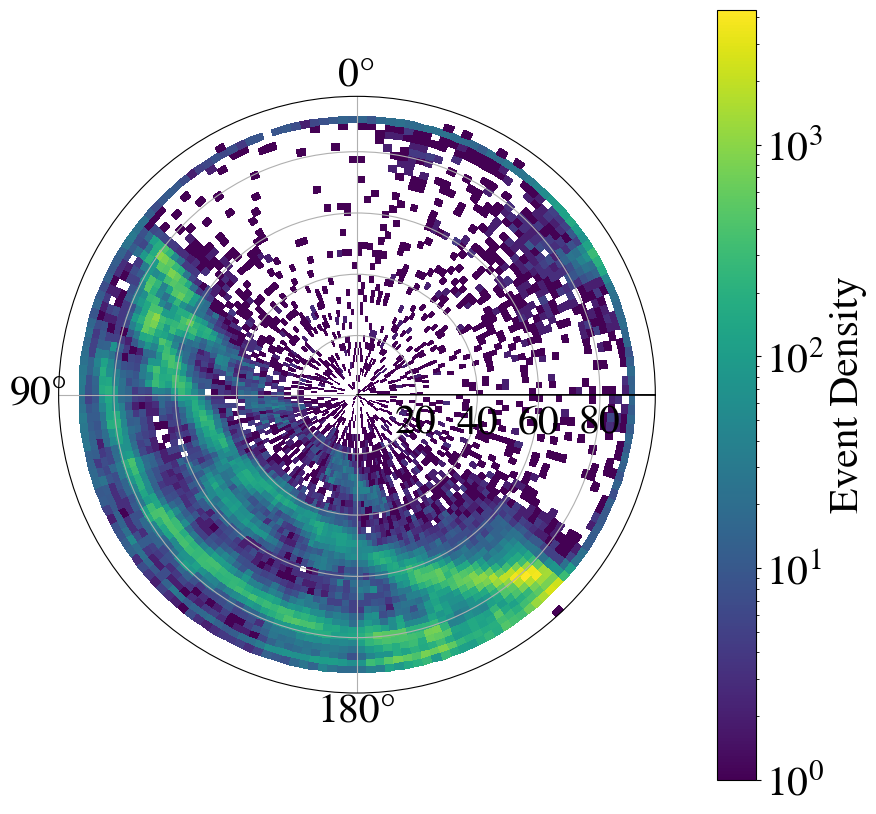

In [ ]:
theta_max = np.array(parasite_theta[run_coincidental_parasite])
phi_max = np.array(parasite_phi[run_coincidental_parasite])

cut_theta_max = theta_max[~cluster_pass_parasite_max]
cut_phi_max = phi_max[~cluster_pass_parasite_max]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location("N")
# ax.set_theta_direction(-1)
# ax.scatter(phi_max,
#             theta_max*180/np.pi,
#             color='blue',
#             alpha=0.7,
#             label='All events'
#             )

hist = ax.hist2d(phi_max-np.pi/2,
                theta_max*180/np.pi,
                bins=[180, 45],
                cmap='viridis',
                # alpha=0.7,
                label='All events',
                norm=mpl.colors.LogNorm(),
                rasterized=True
                )

plt.colorbar(hist[3], 
             ax=ax, 
             label='Event Density',
             pad=0.08
             )

## With the additional zenith cut

In [ ]:

# loop_time_window = np.linspace(2, 30, 30)
loop_time_window = np.logspace(np.log10(.1), np.log10(1e5), 45)
loop_angle_window = np.arange(2, 47, 2)*np.pi/180

cut_efficiency_grid_w_zenith = np.zeros((len(loop_time_window), len(loop_angle_window)))
loss_CR_grid_w_zenith = np.zeros((len(loop_time_window), len(loop_angle_window)))

cut_efficiency_grid_or = np.zeros((len(loop_time_window), len(loop_angle_window)))
loss_CR_grid_or = np.zeros((len(loop_time_window), len(loop_angle_window)))

In [ ]:
cut_by_zenith = 0 # contains the number of events excluded by zenith cut


consecutive_events_cluster_w_zenith = np.array([])
consecutive_events_cluster_or = np.array([])

total_events= 0
total_CR = 0
indicator_full = np.array([])
zenith_pass_indicator_full = np.array([])


count_parasites_w_zenith = np.zeros((len(loop_time_window), len(loop_angle_window)))
count_parasites_or = np.zeros((len(loop_time_window), len(loop_angle_window)))

count_CR_w_zenith = np.zeros((len(loop_time_window), len(loop_angle_window)))
count_CR_or = np.zeros((len(loop_time_window), len(loop_angle_window)))




for run in RUN_valid:
    time_event = np.array(parasite_time_s[run]) - np.min(parasite_time_s[run])
    theta_event = np.array(parasite_theta[run])
    phi_event = np.array(parasite_phi[run])



    zenith_cut_event = (theta_event > 60 *np.pi/180) & (theta_event < 88 *np.pi/180)  # Example cut, adjust as needed
    # time_event = time_event[~zenith_cut]
    # theta_event = theta_event[~zenith_cut]
    # phi_event = phi_event[~zenith_cut]

    cut_by_zenith += np.sum(~zenith_cut_event)


    indicator = np.zeros(len(time_event))

    time_event = np.append(time_event, np.floor(np.array(mockCR_time[run])))
    theta_event = np.append(theta_event, np.array(mockCR_theta[run]*np.pi/180))
    phi_event = np.append(phi_event, np.array(mockCR_phi[run]*np.pi/180))

    zenith_cut_CR = (np.array(mockCR_theta[run]*np.pi/180) > 60 *np.pi/180) & (np.array(mockCR_theta[run]*np.pi/180) < 88 *np.pi/180)
    cut_by_zenith += np.sum(~zenith_cut_CR)


    zenith_pass_indicator = np.concatenate([zenith_cut_event, zenith_cut_CR])


    indicator = np.append(indicator, np.ones(len(mockCR_time[run])))

    sort = np.argsort(time_event)
    time_event = time_event[sort]
    theta_event = theta_event[sort]
    phi_event = phi_event[sort]

    indicator = indicator[sort]
    zenith_pass_indicator = zenith_pass_indicator[sort]
    zenith_CR_indicator = indicator[zenith_pass_indicator]


    total_events += len(time_event)
    total_CR += len(mockCR_time[run])


    consecutive_mask = np.ones(len(time_event)-1, dtype=bool)
    consecutive_mask_zenith = np.ones(len(time_event[zenith_pass_indicator])-1, dtype=bool)

    time_between_consecutive = np.abs(time_event[1:]-time_event[:-1])
    theta_between_consecutive = np.abs(theta_event[1:]-theta_event[:-1])
    phi_between_consecutive = np.abs((phi_event[1:]-phi_event[:-1]+np.pi) % (2*np.pi) - np.pi)


    time_between_consecutive_w_zenith = np.abs(time_event[zenith_pass_indicator][1:]-time_event[zenith_pass_indicator][:-1])
    theta_between_consecutive_w_zenith = np.abs(theta_event[zenith_pass_indicator][1:]-theta_event[zenith_pass_indicator][:-1])
    phi_between_consecutive_w_zenith = np.abs((phi_event[zenith_pass_indicator][1:]-phi_event[zenith_pass_indicator][:-1]+np.pi) % (2*np.pi) - np.pi)


    for i in range(len(loop_time_window)):
        for j in range(len(loop_angle_window)):
            consecutive_mask[np.all([time_between_consecutive < loop_time_window[i], theta_between_consecutive < loop_angle_window[j], phi_between_consecutive < loop_angle_window[j]], axis=0)] = False
            consecutive_mask_zenith[np.all([time_between_consecutive_w_zenith < loop_time_window[i], theta_between_consecutive_w_zenith < loop_angle_window[j], phi_between_consecutive_w_zenith < loop_angle_window[j]], axis=0)] = False
    

            test_cluster_neighbours_w_zenith = np.ones(len(time_event[zenith_pass_indicator]), dtype=bool) # False if either neighbours are in a cluster
            test_cluster_neighbours_or = np.ones(len(time_event), dtype=bool) # False if both neighbour is in a cluster

            for k in range(len(time_event)):
                if k == 0:
                    test_cluster_neighbours_or[k] = consecutive_mask[k]
                elif k == len(time_event)-1:
                    test_cluster_neighbours_or[k] = consecutive_mask[k-1]
                else:
                    test_cluster_neighbours_or[k] = consecutive_mask[k] or consecutive_mask[k-1] 

            for k in range(len(time_event[zenith_pass_indicator])):
                if k == 0:
                    test_cluster_neighbours_w_zenith[k] = consecutive_mask_zenith[k]
                elif k == len(time_event[zenith_pass_indicator])-1:
                    test_cluster_neighbours_w_zenith[k] = consecutive_mask_zenith[k-1]
                else:
                    test_cluster_neighbours_w_zenith[k] = consecutive_mask_zenith[k] or consecutive_mask_zenith[k-1]

            count_parasites_w_zenith[i, j] += np.sum(test_cluster_neighbours_w_zenith[zenith_CR_indicator==0])
            count_parasites_or[i, j] += np.sum(test_cluster_neighbours_or[indicator==0])
            count_CR_w_zenith[i, j] += np.sum(test_cluster_neighbours_w_zenith[zenith_CR_indicator==1])
            count_CR_or[i, j] += np.sum(test_cluster_neighbours_or[indicator==1])
    
    # consecutive_events_cluster_and = np.append(consecutive_events_cluster_and, test_cluster_neighbours_and)
    # consecutive_events_cluster_or = np.append(consecutive_events_cluster_or, test_cluster_neighbours_or)
    # indicator_full = np.append(indicator_full, indicator)


for i in range(len(loop_time_window)):
    for j in range(len(loop_angle_window)):
        cut_efficiency_grid_w_zenith[i, j] = 100 - count_parasites_w_zenith[i, j]/total_events*100
        loss_CR_grid_w_zenith[i, j] = 100 - count_CR_w_zenith[i, j]/total_CR*100

        cut_efficiency_grid_or[i, j] = 100 - count_parasites_or[i, j]/total_events*100
        loss_CR_grid_or[i, j] = 100 - count_CR_or[i, j]/total_CR*100



KeyboardInterrupt: 

In [ ]:
# total cut with zenith included



cmap_angle = plt.colormaps['winter']
norm = mpl.colors.Normalize(vmin=0, vmax=45)

plt.figure(figsize=(10, 6))
ax = plt.gca()

for i in range(len(loop_angle_window)):
    color = cmap_angle(norm(loop_angle_window[i] * 180 / np.pi))
    plt.plot(loop_time_window,
             cut_efficiency_grid_or[:, i],
             color=color,
             marker='o',
             label=f'ClusterCut Efficiency' if i == 0 else ""
             )

    plt.plot(loop_time_window,
             loss_CR_grid_or[:, i],
             color=color,
             marker='x',
             label=f'CR Loss Rate' if i == 0 else "")

    plt.plot(loop_time_window,
             cut_efficiency_grid_w_zenith[:, i],
             color=color,
             marker='s',
             linestyle='--',
             label=f'Cluster Cut Efficiency after Zenith cut' if i == 0 else ""
             )

plt.plot(loop_time_window,
         np.zeros(len(loop_time_window)) + cut_by_zenith / (cut_by_zenith + total_events) * 100,
         color='k',
         linestyle=':',
         label='Cut Efficiency of Zenith cut'
         )
    
# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_angle, norm=norm)
sm.set_array([])  # This is required for the colorbar to work

fig = plt.gcf()
fig.colorbar(sm, ax=ax, label="Angle window (deg)")

plt.xscale('log')
plt.xlabel('Time Window (s)')
plt.yticks(np.array([0, 20, 40, 60, 80, 100]))
plt.ylabel('Percentage (%)')
# plt.title(f'Total Cut Efficiency and CR Loss Rate vs Time Window at fixed angle when preceeded by a zenith cut',
#           wrap=True)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

Xmin = 0.1
index_plot_min = np.argmin(np.abs(loop_angle_window*180/np.pi - Xmin))
Xmax = 100
index_plot_max = np.argmin(np.abs(loop_angle_window*180/np.pi - Xmax))



fig, ax = plt.subplots(1, 2, figsize=(28, 12))
# Plot using pcolor

X0, Y0 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

im0 = ax[0].pcolor(X0,
                   Y0,
                   cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
                   cmap='copper', 
                #    aspect='auto',
                   # origin='lower',
                   norm=mpl.colors.Normalize(
                                    #  vmin=cut_efficiency_grid_or[index_plot_min:index_plot_max, :].min(), 
                                     vmin=0,
                                    #  vmax=100,
                                     vmax= cut_efficiency_grid_or[index_plot_min:index_plot_max, :].max(),
                                     ),
           )

CS = ax[0].contour(X0,
                   Y0,
                   cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
              np.array([50, 65, 75, 95]), 
              colors='k', 
              origin='lower', 
            #   extent=extent
              )
ax[0].clabel(CS, fontsize=25)

        
fig.colorbar(im0, ax=ax[0], label='Cut efficiency (%) ')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'Angle window (deg)',
           fontsize=30
           )
ax[0].set_ylabel('Time window (s)', 
           fontsize=30
           )
# ax[0].set_ylim(
#             #    ymin=1, 
#                ymax=100
#                )
# ax[0].set_title(
#     'Cut efficiency Heatmap', 
#                 fontsize=35
#                 )


X1, Y1 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

im1 = ax[1].pcolor(X1,
                   Y1,
                   loss_CR_grid_or[index_plot_min:index_plot_max, :], 
                    cmap='viridis', 
                    # aspect='auto',
                    # origin='lower',
                    norm=mpl.colors.Normalize(
                                                vmin=0,
                                                #  vmax=100,
                                                vmax=loss_CR_grid_or[index_plot_min:index_plot_max, :].max()
                                                ),
                    )

CS = ax[1].contour(X1,
                   Y1,
                   loss_CR_grid_or[index_plot_min:index_plot_max, :], 
              np.array([0.5, 1, 2, 5, 10]), 
              colors='k', 
            #   origin='lower', 
            #   extent=extent
              )
ax[1].clabel(CS, fontsize=25)

# # Loop over data dimensions and create text annotations.
# for i in range(1, len(loop_time_window), 3):
#     for j in range(1, len(loop_angle_window), 3):
#         text = ax[1].text(j, i, 
#                         f"{loss_CR_grid_or[i, j]:.0f}",
#                        ha="center", 
#                        va="center", 
#                        color="black")
        
fig.colorbar(im1, ax=ax[1], label='CR Loss rate (%) ')

ax[1].set_yscale('log')
ax[1].set_xlabel(r'Angle window (deg)',
           fontsize=30
           )
ax[1].set_ylabel('Time window (s)', 
           fontsize=30
           )

# ax[1].set_ylim(
#             #    ymin=1, 
#                ymax=100
#                )
# ax[1].set_title('Loss rate Heatmap', 
#                 fontsize=35
#                 )

# fig.suptitle('Neighbour cluster (restrictive case)')
plt.show()

if False:
    fig, ax = plt.subplots(1, 2, figsize=(28, 12))
    # Plot using pcolor

    X0, Y0 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

    im0 = ax[0].pcolor(X0,
                    Y0,
                    cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
                    cmap='copper', 
                    #    aspect='auto',
                    # origin='lower',
                    norm=mpl.colors.Normalize(
                                        vmin=cut_efficiency_grid_or[index_plot_min:index_plot_max, :].min(), 
                                        #  vmin=0,
                                        #  vmax=100,
                                        vmax= cut_efficiency_grid_or[index_plot_min:index_plot_max, :].max(),
                                        ),
            )

    CS = ax[0].contour(X0,
                    Y0,
                    cut_efficiency_grid_or[index_plot_min:index_plot_max, :], 
                np.array([50, 65, 75, 95]), 
                colors='k', 
                origin='lower', 
                #   extent=extent
                )
    ax[0].clabel(CS, fontsize=25)

            
    fig.colorbar(im0, ax=ax[0], label='Cut efficiency (%) ')
    ax[0].set_yscale('log')
    ax[0].set_xlabel(r'Angle window (deg)',
            fontsize=30
            )
    ax[0].set_ylabel('Time window (s)', 
            fontsize=30
            )


    X1, Y1 = np.meshgrid(loop_angle_window*180/np.pi, loop_time_window[index_plot_min:index_plot_max])

    im1 = ax[1].pcolor(X1,
                    Y1,
                    loss_CR_grid_or[index_plot_min:index_plot_max, :], 
                        cmap='viridis', 
                        # aspect='auto',
                        # origin='lower',
                        norm=mpl.colors.Normalize(
                                                    vmin=0,
                                                    #  vmax=100,
                                                    vmax=loss_CR_grid_or[index_plot_min:index_plot_max, :].max()
                                                    ),
                        )

    CS = ax[1].contour(X1,
                    Y1,
                    loss_CR_grid_or[index_plot_min:index_plot_max, :], 
                np.array([0.5, 1, 2, 5, 10]), 
                colors='k', 
                #   origin='lower', 
                #   extent=extent
                )
    ax[1].clabel(CS, fontsize=25)

    # # Loop over data dimensions and create text annotations.
    # for i in range(1, len(loop_time_window), 3):
    #     for j in range(1, len(loop_angle_window), 3):
    #         text = ax[1].text(j, i, 
    #                         f"{loss_CR_grid_or[i, j]:.0f}",
    #                        ha="center", 
    #                        va="center", 
    #                        color="black")
            
    fig.colorbar(im1, ax=ax[1], label='CR Loss rate (%) ')

    ax[1].set_yscale('log')
    ax[1].set_xlabel(r'Angle window (deg)',
            fontsize=30
            )
    ax[1].set_ylabel('Time window (s)', 
            fontsize=30
            )